# Evaluating the cross-attention probe: does alignment help predict physics?

In this notebook we evaluate the contrastive cross-attention head trained in this tutorial
(see `README.md`), by asking a very concrete question:

> **Do the aligned embeddings encode more physics than the raw AION tokens?**

Following the protocol of our earlier [AstroCLIP tutorial](../AstroCLIPTutorial.ipynb), we use a
**k-Nearest Neighbors regressor** on top of frozen embeddings to predict two galaxy properties
from the PROVABGS catalog:

- **redshift** (`Z_HP_provabgs`)
- **stellar mass** (`LOG_MSTAR_provabgs`)

and we compare two ways of turning AION token sequences into a single vector per galaxy:

| pooling | description | trained? |
|---|---|---|
| **cross-attention probe** | our `CrossAttentionPool` with modality-specific learned queries, trained contrastively | yes (on image/spectrum pairing only) |
| **mean pooling** | simply average the 768-d AION tokens | no |

The k-NN protocol is intentionally primitive: if galaxies that are close in embedding space have
similar redshifts, the embedding "knows" about redshift. Any difference between the two rows of
the table above is attributable to the contrastive alignment, since **neither method ever saw
redshift or stellar mass labels during training**.

In [1]:
# ------------------------- settings -------------------------------------- #
# The wandb run whose best checkpoint we evaluate. Training can have happened
# on any machine: the model is downloaded from wandb, not from local disk.
WANDB_RUN = "eiffl/aion-contrastive/expzhwkb"

# The embeddings dataset: the public Hub dataset by default. If you have the
# parquet shards locally, put the directory here instead to skip the download.
DATASET = "/local/home/flanusse/repo/FoundationModelTutorial/aion_embeddings/desi_x_ls_aion"
# DATASET = "EiffL/desi_x_ls_aion"

In [2]:
# On Colab (or any machine without this repo), fetch the code + dependencies.
try:
    import aion_contrastive  # noqa: F401
except ImportError:
    !git clone --depth 1 https://github.com/EiffL/Tutorials
    %cd Tutorials/FoundationModels/AION
    %pip install -q -r requirements.txt

/local/home/flanusse/repo/Tutorials/FoundationModels/AION/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import glob, os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from aion_contrastive import ContrastiveAlignment, AIONEmbeddingDataModule

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 1. Download the trained probe from wandb

During training, `WandbLogger(log_model="all")` pushed every checkpoint to wandb as a
**model artifact**; the alias `best` always points to the checkpoint with the lowest
`val/loss`. So all we need to locate the model is the run reference at the top of this
notebook — the training can have happened on a cluster while this notebook runs on a laptop
or Colab. `load_from_checkpoint` restores both weights and hyperparameters, because the
`LightningModule` called `save_hyperparameters()` in its `__init__`.

In [4]:
import wandb

# Lightning's WandbLogger (log_model: all) stores every checkpoint of a run as
# versions of an artifact named "model-<run_id>", and keeps the alias "best"
# pointing at the checkpoint with the best monitored metric (val/loss here).
entity_project, run_id = WANDB_RUN.rsplit("/", 1)
artifact = wandb.Api().artifact(f"{entity_project}/model-{run_id}:best", type="model")
ckpt_path = os.path.join(artifact.download(), "model.ckpt")
print("downloaded:", ckpt_path)

model = ContrastiveAlignment.load_from_checkpoint(ckpt_path, map_location=device).eval().to(device)
print(f"probe parameters: {sum(p.numel() for p in model.parameters())/1e6:.1f} M")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /local/home/flanusse/.netrc.


wandb: Downloading large artifact 'model-expzhwkb:best', 81.28MB. 1 files...


wandb:   1 of 1 files downloaded.  


Done. 00:00:02.0 (39.9MB/s)


downloaded: /local/home/flanusse/repo/Tutorials/FoundationModels/AION/artifacts/model-expzhwkb:v0/model.ckpt


probe parameters: 7.1 M


## 2. Embed the validation set

We reuse the `AIONEmbeddingDataModule` with the exact same settings as training, so the
validation split is identical: a fixed-seed 2% row-level split, which the probe **never saw
during training** — and which is reproducible on any machine. For every galaxy we compute four
embeddings:

- image / spectrum through the **cross-attention probe** (768-d, L2-normalized),
- image / spectrum by **mean-pooling** the raw AION tokens (768-d).

In [5]:
dm = AIONEmbeddingDataModule(dataset=DATASET, batch_size=256, num_workers=8)
dm.prepare_data(); dm.setup()
print("validation galaxies:", len(dm.val_dataset))

validation galaxies: 1918


In [6]:
from collections import defaultdict

results = defaultdict(list)
with torch.no_grad():
    for batch in dm.val_dataloader():
        image = batch["image"].to(device)
        spectrum = batch["spectrum"].to(device)

        results["attn_image"].append(model.embed_image(image).cpu())
        results["attn_spectrum"].append(model.embed_spectrum(spectrum).cpu())
        # Mean pooling: average the frozen AION tokens, nothing learned at all.
        results["mean_image"].append(image.mean(dim=1).cpu())
        results["mean_spectrum"].append(spectrum.mean(dim=1).cpu())

        results["redshift"].append(batch["Z_HP_provabgs"])
        results["log_mstar"].append(batch["LOG_MSTAR_provabgs"])

data = {k: torch.cat(v).numpy() for k, v in results.items()}
{k: v.shape for k, v in data.items()}

{'attn_image': (1918, 768),
 'attn_spectrum': (1918, 768),
 'mean_image': (1918, 768),
 'mean_spectrum': (1918, 768),
 'redshift': (1918,),
 'log_mstar': (1918,)}

## 3. k-NN regression

Exactly as in the AstroCLIP tutorial: split the galaxies into a train/test set, fit a
`KNeighborsRegressor` on the training embeddings, and predict on the test set.

Two methodological details:

- We **L2-normalize every embedding** before the k-NN, so that Euclidean neighbors are cosine
  neighbors for both methods. The probe's embeddings are already normalized (they live on the
  sphere where the contrastive loss operates), so this simply puts mean pooling on the same
  footing.
- We report **three metrics**, because they can genuinely disagree (see below):
  - `R2` — the usual coefficient of determination, a *squared*-error metric;
  - `med AE` — median absolute error, the precision for the *typical* galaxy;
  - `outlier %` — the fraction of catastrophic errors ($|\Delta z| > 0.05(1+z)$ for redshift,
    $|\Delta| > 0.5$ dex for mass), the photo-z convention.

In [7]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.metrics import r2_score


def knn_evaluate(embedding, target, outlier_threshold, n_neighbors=10, test_size=0.2, seed=42):
    """Fit a k-NN regressor on frozen embeddings and compute both squared-error
    and robust metrics. `outlier_threshold` is a function of the true value
    defining a catastrophic error (photo-z convention)."""
    X = normalize(embedding)
    X_tr, X_te, y_tr, y_te = train_test_split(X, target, test_size=test_size, random_state=seed)
    knn = KNeighborsRegressor(n_neighbors=n_neighbors, weights="distance")
    knn.fit(X_tr, y_tr)
    y_pred = knn.predict(X_te)

    resid = y_pred - y_te
    metrics = {
        "R2": r2_score(y_te, y_pred),
        "med AE": np.median(np.abs(resid)),
        "outlier %": 100 * np.mean(np.abs(resid) > outlier_threshold(y_te)),
    }
    return metrics, y_te, y_pred

In [8]:
embeddings = ["attn_image", "mean_image", "attn_spectrum", "mean_spectrum"]
# Catastrophic-error definitions: the photo-z convention for redshift,
# half a dex for stellar mass.
targets = {
    "redshift": ("redshift", lambda y: 0.05 * (1 + y)),
    "log M*": ("log_mstar", lambda y: 0.5),
}

rows, predictions = [], {}
for name in embeddings:
    for target_label, (target_key, thresh) in targets.items():
        metrics, y_te, y_pred = knn_evaluate(data[name], data[target_key], thresh)
        rows.append({"embedding": name, "target": target_label, **metrics})
        predictions[(name, target_label)] = (y_te, y_pred)

scores = pd.DataFrame(rows).pivot(index="embedding", columns="target",
                                  values=["R2", "med AE", "outlier %"])
scores.round(4)

R2           med AE          outlier %         
target         log M* redshift  log M* redshift    log M* redshift
embedding                                                         
attn_image     0.7369   0.7416  0.1841   0.0268   14.3229  22.9167
attn_spectrum  0.8505   0.9472  0.1491   0.0124    6.2500   3.1250
mean_image     0.6707   0.6818  0.2092   0.0339   16.4062  29.4271
mean_spectrum  0.7946   0.9770  0.1765   0.0009    8.5938   2.8646

## 4. True vs. predicted

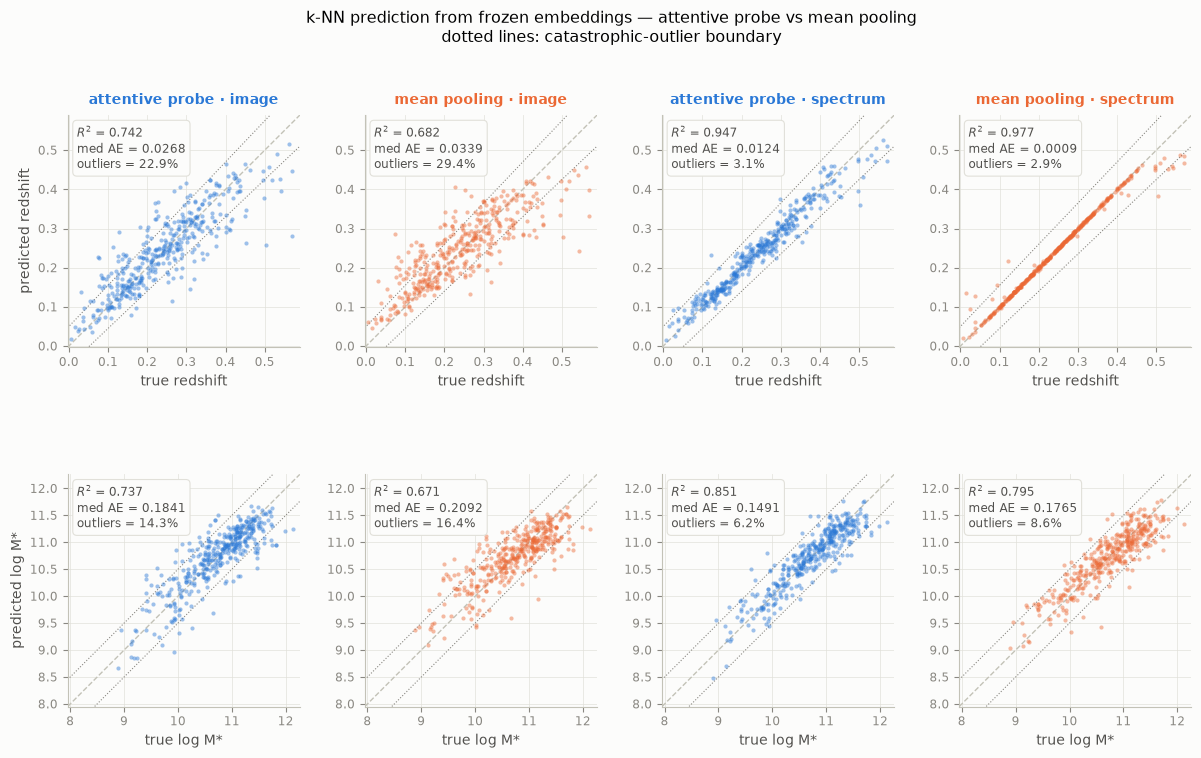

In [9]:
# Styling: blue = attentive probe, orange = mean pooling; recessive chrome.
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK2, MUTED, GRID, BASE, SURF = "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
colors = {"attn_image": BLUE, "mean_image": ORANGE,
          "attn_spectrum": BLUE, "mean_spectrum": ORANGE}
panel_titles = {"attn_image": "attentive probe · image", "mean_image": "mean pooling · image",
                "attn_spectrum": "attentive probe · spectrum", "mean_spectrum": "mean pooling · spectrum"}

fig, axes = plt.subplots(2, 4, figsize=(14.5, 8.2), facecolor=SURF,
                         gridspec_kw={"hspace": 0.32, "wspace": 0.28})
for i, (target_label, (target_key, thresh)) in enumerate(targets.items()):
    y_all = data[target_key]
    lo, hi = np.percentile(y_all, [0.5, 99.5])
    pad = 0.04 * (hi - lo); lo, hi = lo - pad, hi + pad
    for j, name in enumerate(embeddings):
        ax = axes[i, j]; ax.set_facecolor(SURF)
        y_te, y_pred = predictions[(name, target_label)]

        xs = np.linspace(lo, hi, 100)
        ax.plot(xs, xs, ls="--", lw=1, color=BASE, zorder=1)
        # catastrophic-outlier boundary, so the "outlier %" metric is visible
        ax.plot(xs, xs + thresh(xs), ls=":", lw=0.8, color=MUTED, zorder=1)
        ax.plot(xs, xs - thresh(xs), ls=":", lw=0.8, color=MUTED, zorder=1)
        ax.scatter(y_te, y_pred, s=9, alpha=0.45, color=colors[name], lw=0, zorder=2)

        r2 = scores.loc[name, ("R2", target_label)]
        med = scores.loc[name, ("med AE", target_label)]
        outl = scores.loc[name, ("outlier %", target_label)]
        ax.text(0.04, 0.96, f"$R^2$ = {r2:.3f}\nmed AE = {med:.4f}\noutliers = {outl:.1f}%",
                transform=ax.transAxes, va="top", fontsize=8.5, color=INK2,
                bbox=dict(boxstyle="round,pad=0.35", fc=SURF, ec=GRID, lw=0.8))

        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
        ax.grid(color=GRID, lw=0.6, alpha=0.8); ax.set_axisbelow(True)
        ax.tick_params(colors=MUTED, labelsize=8.5)
        for s in ("top", "right"): ax.spines[s].set_visible(False)
        for s in ("left", "bottom"): ax.spines[s].set_color(BASE)
        if i == 0: ax.set_title(panel_titles[name], color=colors[name], fontweight="bold", pad=8, fontsize=10)
        if j == 0: ax.set_ylabel(f"predicted {target_label}", color=INK2)
        ax.set_xlabel(f"true {target_label}", color=INK2)

fig.suptitle("k-NN prediction from frozen embeddings — attentive probe vs mean pooling\n"
             "dotted lines: catastrophic-outlier boundary", fontsize=11.5, y=0.985);

## 5. What to conclude — and a lesson about metrics

**Look at the `mean_spectrum` / redshift panel** before reading the table: nearly every point
sits *exactly* on the diagonal, yet its $R^2$ is slightly **lower** than the visibly blurrier
`attn_spectrum` panel. This is not a bug — it is the whole reason we report three metrics:

- `mean_spectrum` is **~10× more precise for the typical galaxy** (`med AE` ≈ 0.001 vs 0.01):
  a raw AION spectrum embedding essentially *contains* the redshift. But it also produces
  ~2× more **catastrophic outliers**, and because $R^2$ squares the errors, a handful of
  disasters dominates it entirely (the worst few points carry most of the total squared error).
- The contrastive probe, by projecting into the shared image/spectrum space, **blurs the fine
  redshift information** (it only ever needed to be precise enough to match pairs within a
  batch — nothing in the InfoNCE objective rewards the third decimal of $z$) but produces a
  more **robust** embedding with fewer disasters. $R^2$ only sees the second effect.

The broader conclusions:

- **The probe helps on images**: consistent gains on both targets, largest for stellar mass.
  Note however that mean pooling is a much stronger baseline than in AstroCLIP — AION is
  already a multimodal model, so its image tokens were aligned with spectral information
  during pretraining; the dramatic "spectra teach the image encoder" effect mostly already
  happened inside AION.
- **Contrastive spaces are organized for retrieval, not regression**: matching pairs across
  modalities requires coarse physical agreement, not precision. If your downstream task is
  precision redshifts from spectra, use the raw embeddings (or add a redshift-aware objective);
  if it is cross-modal search or robust characterization, the aligned space is the better tool.
- **Never judge a regressor by a single metric** — plot true vs. predicted, and separate the
  typical error from the failure rate.

### Exercises

1. Vary `n_neighbors` — is the ranking between methods stable across all three metrics?
2. Replace k-NN with a small MLP regressor (`sklearn.neural_network.MLPRegressor`). Does the gap
   between cross-attention and mean pooling shrink? What would that tell you?
3. Try the untrained probe: instantiate `ContrastiveAlignment()` without loading the checkpoint
   and rerun. How much of the performance comes from training vs. the architecture prior?
4. Concatenate image and spectrum embeddings — does the combination beat either alone?
5. Inspect the catastrophic outliers of `mean_spectrum`: plot their spectra tokens' nearest
   neighbors. Can you tell *why* the k-NN failed (e.g. line confusion between low-z and
   high-z look-alikes)?